<div style="border:solid green 2px; padding: 20px">
<b>Привет!</b>

Меня зовут Михаленко Дмитрий, и я буду проверять твой проект. Предлагаю общаться на «ты» :) Но если это не удобно - дай знать, и мы перейдем на "вы". 

Моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе стать аналитиком данных. Ты уже проделал большую работу над проектом, но давай сделаем его еще лучше. Ниже ты найдешь мои комментарии - **пожалуйста, не перемещай, не изменяй и не удаляй их**. Увидев у тебя ошибку, в первый раз я лишь укажу на ее наличие и дам тебе возможность самому найти и исправить ее. На реальной работе твой начальник будет поступать так же, а я пытаюсь подготовить тебя именно к работе аналитиком. Но если ты пока не справишься с такой задачей - при следующей проверке я дам более точную подсказку. Я буду использовать цветовую разметку:

<div class="alert alert-danger">
<b>Комментарий ревьюера ❌:</b> Так выделены самые важные замечания. Без их отработки проект не будет принят. </div>

<div class="alert alert-warning">
<b>Комментарий ревьюера ⚠️:</b> Так выделены небольшие замечания. Я надеюсь, что их ты тоже учтешь - твой проект от этого станет только лучше. Но настаивать на их отработке не буду.

</div>

<div class="alert alert-success">
<b>Комментарий ревьюера ✔️:</b> Так я выделяю все остальные комментарии.</div>

Давай работать над проектом в диалоге: **если ты что-то меняешь в проекте или отвечаешь на мои комментарии — пиши об этом.** Мне будет легче отследить изменения, если ты выделишь свои комментарии:
<div class="alert alert-info"> <b>Комментарий студента:</b> Например, вот так.</div>

Всё это поможет выполнить повторную проверку твоего проекта оперативнее.

#### Описание проекта
- Вы — маркетинговый аналитик развлекательного приложения Procrastinate Pro+. Несмотря на огромные вложения в рекламу, последние несколько месяцев компания терпит убытки. Ваша задача — разобраться в причинах и помочь компании выйти в плюс.
- Есть данные о пользователях, привлечённых с 1 мая по 27 октября 2019 года:
  - лог сервера с данными об их посещениях,
  - выгрузка их покупок за этот период,
  - рекламные расходы.
- Вам предстоит изучить:
  - откуда приходят пользователи и какими устройствами они пользуются,
  - сколько стоит привлечение пользователей из различных рекламных каналов;
  - сколько денег приносит каждый клиент,
  - когда расходы на привлечение клиента окупаются,
  - какие факторы мешают привлечению клиентов.

<div class="alert alert-success">
<b>Комментарий ревьюера ✔️:</b> Хорошая продуктовая задача</div>

#### ШАГ 1
#### подготовка данных

     оглавление:
 - [Шаг 2 загрузка функций](#part_2)
 - [Шаг 3 исследовательский анализ данных](#part_3)
 - [Шаг 4 маркетинг](#part_4)
 - [Шаг 5 оценка окупаемости рекламы](#part_5)
 - [Вывод](#sum)


In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta, date
from matplotlib import pyplot as plt
import seaborn as sns
import os


In [3]:
pth1 = '/Users/ikashkovskiy/Desktop/YANDEX P/data/procrastinate_pro/orders_info_short.csv'
pth2 = '/datasets/orders_info_short.csv'
pth3 = '/Users/ikashkovskiy/Desktop/YANDEX P/data/procrastinate_pro/visits_info_short.csv'
pth4 = '/datasets/visits_info_short.csv'
pth5 = '/Users/ikashkovskiy/Desktop/YANDEX P/data/procrastinate_pro/costs_info_short.csv'
pth6 = '/datasets/costs_info_short.csv'

if os.path.exists(pth1) and os.path.exists(pth3) and os.path.exists(pth5):
    orders = pd.read_csv(pth1)
    visits = pd.read_csv(pth3)  
    costs = pd.read_csv(pth5) 
elif os.path.exists(pth2) and os.path.exists(pth4) and os.path.exists(pth6):
    orders = pd.read_csv(pth2)
    visits = pd.read_csv(pth4)  
    costs = pd.read_csv(pth6) 
else:
    print('Something is wrong')

display(orders.head(5))  # заказы
display(visits.head(5))  # посещения
display(costs.head(5)) # стоимость привлечения




,User Id,Event Dt,Revenue
0,188246423999,2019-05-01 23:09:52,4.99
1,174361394180,2019-05-01 12:24:04,4.99
2,529610067795,2019-05-01 11:34:04,4.99
3,319939546352,2019-05-01 15:34:40,4.99
4,366000285810,2019-05-01 13:59:51,4.99


,User Id,Region,Device,Channel,Session Start,Session End
0,981449118918,United States,iPhone,organic,2019-05-01 02:36:01,2019-05-01 02:45:01
1,278965908054,United States,iPhone,organic,2019-05-01 04:46:31,2019-05-01 04:47:35
2,590706206550,United States,Mac,organic,2019-05-01 14:09:25,2019-05-01 15:32:08
3,326433527971,United States,Android,TipTop,2019-05-01 00:29:59,2019-05-01 00:54:25
4,349773784594,United States,Mac,organic,2019-05-01 03:33:35,2019-05-01 03:57:40


,dt,Channel,costs
0,2019-05-01,FaceBoom,113.3
1,2019-05-02,FaceBoom,78.1
2,2019-05-03,FaceBoom,85.8
3,2019-05-04,FaceBoom,136.4
4,2019-05-05,FaceBoom,122.1


In [4]:
orders.columns = orders.columns.str.lower()
visits.columns = visits.columns.str.lower()
costs.columns = costs.columns.str.lower()

In [5]:
orders = orders.rename(columns={
  'user id' : 'user_id',
  'event dt' : 'event_dt'
})

In [6]:
visits = visits.rename(columns={
  'user id' : 'user_id',
  'session start' : 'session_start',
  'session end' : 'session_end'  
})

In [7]:
# преобразование данных о времени
visits['session_start'] = pd.to_datetime(visits['session_start'])
visits['session_end'] = pd.to_datetime(visits['session_end'])
orders['event_dt'] = pd.to_datetime(orders['event_dt'])
costs['dt'] = pd.to_datetime(costs['dt']).dt.date

In [8]:
display(orders.isna().sum()) #пропусков нет

user_id     0
event_dt    0
revenue     0
dtype: int64

In [9]:
visits.duplicated().sum()  #дубликатов нет

0

<div class="alert alert-success">
<b>Комментарий ревьюера ✔️:</b> Отлично, даты переведены в нужный формат, проверены дубликаты и пропуски, использован snake_case </div>

<div class="alert alert-danger">
<b>Комментарий ревьюера ❌:</b> Но все же стоит написать хотя бы небольшой промежуточный вывод по предобработке)

#### ШАГ 2  
##### загрузка фунций
<a id='part_2'></a>

In [10]:
# профили

def get_profiles(sessions, orders, events, ad_costs, event_names=[]):

    # находим параметры первых посещений
    profiles = (
        visits.sort_values(by=['user_id', 'session_start'])
        .groupby('user_id')
        .agg(
            {
                'session_start': 'first',
                'channel': 'first',
                'device': 'first',
                'region': 'first',
            }
        )
        .rename(columns={'session_start': 'first_ts'})
        .reset_index()
    )

    # для когортного анализа определяем дату первого посещения
    # и первый день месяца, в который это посещение произошло
    profiles['dt'] = profiles['first_ts'].dt.date
    profiles['month'] = profiles['first_ts'].astype('datetime64[M]')

    # добавляем признак платящих пользователей
    profiles['payer'] = profiles['user_id'].isin(orders['user_id'].unique())

    # добавляем флаги для всех событий из event_names
    for event in event_names:
        if event in events['event_name'].unique():
            profiles[event] = profiles['user_id'].isin(
                events.query('event_name == @event')['user_id'].unique()
            )

    # считаем количество уникальных пользователей
    # с одинаковыми источником и датой привлечения
    new_users = (
        profiles.groupby(['dt', 'channel'])
        .agg({'user_id': 'nunique'})
        .rename(columns={'user_id': 'unique_users'})
        .reset_index()
    )

    # объединяем траты на рекламу и число привлечённых пользователей
    ad_costs = ad_costs.merge(new_users, on=['dt', 'channel'], how='left')

    # делим рекламные расходы на число привлечённых пользователей
    ad_costs['acquisition_cost'] = ad_costs['costs'] / ad_costs['unique_users']

    # добавляем стоимость привлечения в профили
    profiles = profiles.merge(
        ad_costs[['dt', 'channel', 'acquisition_cost']],
        on=['dt', 'channel'],
        how='left',
    )

    # стоимость привлечения органических пользователей равна нулю
    profiles['acquisition_cost'] = profiles['acquisition_cost'].fillna(0)

    return profiles

In [11]:
# функция для расчёта удержания

def get_retention(
    profiles,
    sessions,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # добавляем столбец payer в передаваемый dimensions список
    dimensions = ['payer'] + dimensions

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # собираем «сырые» данные для расчёта удержания
    result_raw = result_raw.merge(
        sessions[['user_id', 'session_start']], on='user_id', how='left'
    )
    result_raw['lifetime'] = (
        result_raw['session_start'] - result_raw['first_ts']
    ).dt.days

    # функция для группировки таблицы по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique'
        )
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    # получаем таблицу удержания
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # получаем таблицу динамики удержания
    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    # возвращаем обе таблицы и сырые данные
    return result_raw, result_grouped, result_in_time

In [12]:
# функция для расчёта конверсии

def get_conversion(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # определяем дату и время первой покупки для каждого пользователя
    first_purchases = (
        purchases.sort_values(by=['user_id', 'event_dt'])
        .groupby('user_id')
        .agg({'event_dt': 'first'})
        .reset_index()
    )

    # добавляем данные о покупках в профили
    result_raw = result_raw.merge(
        first_purchases[['user_id', 'event_dt']], on='user_id', how='left'
    )

    # рассчитываем лайфтайм для каждой покупки
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days

    # группируем по cohort, если в dimensions ничего нет
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users' 
        dimensions = dimensions + ['cohort']

    # функция для группировки таблицы по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique'
        )
        result = result.fillna(0).cumsum(axis = 1)
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        # делим каждую «ячейку» в строке на размер когорты
        # и получаем conversion rate
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    # получаем таблицу конверсии
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # для таблицы динамики конверсии убираем 'cohort' из dimensions
    if 'cohort' in dimensions: 
        dimensions = []

    # получаем таблицу динамики конверсии
    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    # возвращаем обе таблицы и сырые данные
    return result_raw, result_grouped, result_in_time

In [13]:
# функция для расчёта LTV и ROI

def get_ltv(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')
    # добавляем данные о покупках в профили
    result_raw = result_raw.merge(
        purchases[['user_id', 'event_dt', 'revenue']], on='user_id', how='left'
    )
    # рассчитываем лайфтайм пользователя для каждой покупки
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days
    # группируем по cohort, если в dimensions ничего нет
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users'
        dimensions = dimensions + ['cohort']

    # функция группировки по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        # строим «треугольную» таблицу выручки
        result = df.pivot_table(
            index=dims, columns='lifetime', values='revenue', aggfunc='sum'
        )
        # находим сумму выручки с накоплением
        result = result.fillna(0).cumsum(axis=1)
        # вычисляем размеры когорт
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        # объединяем размеры когорт и таблицу выручки
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        # считаем LTV: делим каждую «ячейку» в строке на размер когорты
        result = result.div(result['cohort_size'], axis=0)
        # исключаем все лайфтаймы, превышающие горизонт анализа
        result = result[['cohort_size'] + list(range(horizon_days))]
        # восстанавливаем размеры когорт
        result['cohort_size'] = cohort_sizes

        # собираем датафрейм с данными пользователей и значениями CAC, 
        # добавляя параметры из dimensions
        cac = df[['user_id', 'acquisition_cost'] + dims].drop_duplicates()

        # считаем средний CAC по параметрам из dimensions
        cac = (
            cac.groupby(dims)
            .agg({'acquisition_cost': 'mean'})
            .rename(columns={'acquisition_cost': 'cac'})
        )

        # считаем ROI: делим LTV на CAC
        roi = result.div(cac['cac'], axis=0)

        # удаляем строки с бесконечным ROI
        roi = roi[~roi['cohort_size'].isin([np.inf])]

        # восстанавливаем размеры когорт в таблице ROI
        roi['cohort_size'] = cohort_sizes

        # добавляем CAC в таблицу ROI
        roi['cac'] = cac['cac']

        # в финальной таблице оставляем размеры когорт, CAC
        # и ROI в лайфтаймы, не превышающие горизонт анализа
        roi = roi[['cohort_size', 'cac'] + list(range(horizon_days))]

        # возвращаем таблицы LTV и ROI
        return result, roi

    # получаем таблицы LTV и ROI
    result_grouped, roi_grouped = group_by_dimensions(
        result_raw, dimensions, horizon_days
    )

    # для таблиц динамики убираем 'cohort' из dimensions
    if 'cohort' in dimensions:
        dimensions = []

    # получаем таблицы динамики LTV и ROI
    result_in_time, roi_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    return (
        result_raw,  # сырые данные
        result_grouped,  # таблица LTV
        result_in_time,  # таблица динамики LTV
        roi_grouped,  # таблица ROI
        roi_in_time,  # таблица динамики ROI
    )

In [14]:
# функция для сглаживания фрейма

def filter_data(df, window):
    # для каждого столбца применяем скользящее среднее
    for column in df.columns.values:
        df[column] = df[column].rolling(window).mean() 
    return df

In [15]:
# функция для визуализации удержания

def plot_retention(retention, retention_history, horizon, window=7):

    # задаём размер сетки для графиков
    plt.figure(figsize=(15, 10))

    # исключаем размеры когорт и удержание первого дня
    retention = retention.drop(columns=['cohort_size', 0])
    # в таблице динамики оставляем только нужный лайфтайм
    retention_history = retention_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]

    # если в индексах таблицы удержания только payer,
    # добавляем второй признак — cohort
    if retention.index.nlevels == 1:
        retention['cohort'] = 'All users'
        retention = retention.reset_index().set_index(['cohort', 'payer'])

    # в таблице графиков — два столбца и две строки, четыре ячейки
    # в первой строим кривые удержания платящих пользователей
    ax1 = plt.subplot(2, 2, 1)
    retention.query('payer == True').droplevel('payer').T.plot(
        grid=True, ax=ax1
    )
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Удержание платящих пользователей')

    # во второй ячейке строим кривые удержания неплатящих
    # вертикальная ось — от графика из первой ячейки
    ax2 = plt.subplot(2, 2, 2, sharey=ax1)
    retention.query('payer == False').droplevel('payer').T.plot(
        grid=True, ax=ax2
    )
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Удержание неплатящих пользователей')

    # в третьей ячейке — динамика удержания платящих
    ax3 = plt.subplot(2, 2, 3)
    # получаем названия столбцов для сводной таблицы
    columns = [
        name
        for name in retention_history.index.names
        if name not in ['dt', 'payer']
    ]
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == True').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title(
        'Динамика удержания платящих пользователей на {}-й день'.format(
            horizon
        )
    )

    # в чётвертой ячейке — динамика удержания неплатящих
    ax4 = plt.subplot(2, 2, 4, sharey=ax3)
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == False').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax4)
    plt.xlabel('Дата привлечения')
    plt.title(
        'Динамика удержания неплатящих пользователей на {}-й день'.format(
            horizon
        )
    )
    
    plt.tight_layout()
    plt.show()

In [16]:
# функция для визуализации конверсии

def plot_conversion(conversion, conversion_history, horizon, window=7):

    # задаём размер сетки для графиков
    plt.figure(figsize=(15, 5))

    # исключаем размеры когорт
    conversion = conversion.drop(columns=['cohort_size'])
    # в таблице динамики оставляем только нужный лайфтайм
    conversion_history = conversion_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]

    # первый график — кривые конверсии
    ax1 = plt.subplot(1, 2, 1)
    conversion.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Конверсия пользователей')

    # второй график — динамика конверсии
    ax2 = plt.subplot(1, 2, 2, sharey=ax1)
    columns = [
        # столбцами сводной таблицы станут все столбцы индекса, кроме даты
        name for name in conversion_history.index.names if name not in ['dt']
    ]
    filtered_data = conversion_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика конверсии пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show()

In [17]:
# функция для визуализации LTV и ROI

def plot_ltv_roi(ltv, ltv_history, roi, roi_history, horizon, window=7):

    # задаём сетку отрисовки графиков
    plt.figure(figsize=(20, 10))

    # из таблицы ltv исключаем размеры когорт
    ltv = ltv.drop(columns=['cohort_size'])
    # в таблице динамики ltv оставляем только нужный лайфтайм
    ltv_history = ltv_history.drop(columns=['cohort_size'])[[horizon - 1]]

    # стоимость привлечения запишем в отдельный фрейм
    cac_history = roi_history[['cac']]

    # из таблицы roi исключаем размеры когорт и cac
    roi = roi.drop(columns=['cohort_size', 'cac'])
    # в таблице динамики roi оставляем только нужный лайфтайм
    roi_history = roi_history.drop(columns=['cohort_size', 'cac'])[
        [horizon - 1]
    ]

    # первый график — кривые ltv
    ax1 = plt.subplot(2, 3, 1)
    ltv.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('LTV')

    # второй график — динамика ltv
    ax2 = plt.subplot(2, 3, 2, sharey=ax1)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in ltv_history.index.names if name not in ['dt']]
    filtered_data = ltv_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика LTV пользователей на {}-й день'.format(horizon))

    # третий график — динамика cac
    ax3 = plt.subplot(2, 3, 3, sharey=ax1)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in cac_history.index.names if name not in ['dt']]
    filtered_data = cac_history.pivot_table(
        index='dt', columns=columns, values='cac', aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика стоимости привлечения пользователей')

    # четвёртый график — кривые roi
    ax4 = plt.subplot(2, 3, 4)
    roi.T.plot(grid=True, ax=ax4)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('ROI')

    # пятый график — динамика roi
    ax5 = plt.subplot(2, 3, 5, sharey=ax4)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in roi_history.index.names if name not in ['dt']]
    filtered_data = roi_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax5)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.xlabel('Дата привлечения')
    plt.title('Динамика ROI пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show()

<div class="alert alert-success">
<b>Комментарий ревьюера ✔️:</b> Необходимые функции загружены </div>

#### ШАГ 3  
##### исследовательский анализ данных
<a id='part_3'></a>

In [18]:
# 3 

#Составьте профили пользователей.

#Определите минимальную и максимальную даты привлечения пользователей.

#Выясните, из каких стран пользователи приходят в приложение и на какую страну приходится больше 
#всего платящих пользователей. 

#Постройте таблицу, отражающую количество пользователей и долю платящих из каждой страны.

#Узнайте, какими устройствами пользуются клиенты и какие устройства предпочитают платящие пользователи. 

#Постройте таблицу, отражающую количество пользователей и долю платящих для каждого устройства.

#Изучите рекламные источники привлечения и определите каналы, из которых пришло больше всего платящих пользователей.

#Постройте таблицу, отражающую количество пользователей и долю платящих для каждого канала привлечения.


In [19]:
profiles = get_profiles(visits, orders, costs, costs)
profiles.head(5)

,user_id,first_ts,channel,device,region,dt,month,payer,acquisition_cost
0,599326,2019-05-07 20:58:57,FaceBoom,Mac,United States,2019-05-07,2019-05-01,True,1.088172
1,4919697,2019-07-09 12:46:07,FaceBoom,iPhone,United States,2019-07-09,2019-07-01,False,1.107237
2,6085896,2019-10-01 09:58:33,organic,iPhone,France,2019-10-01,2019-10-01,False,0.000000
3,22593348,2019-08-22 21:35:48,AdNonSense,PC,Germany,2019-08-22,2019-08-01,False,0.988235
4,31989216,2019-10-02 00:07:44,YRabbit,iPhone,United States,2019-10-02,2019-10-01,False,0.230769


In [20]:
#Определите минимальную дату привлечения пользователей.

profiles['first_ts'].min()

Timestamp('2019-05-01 00:00:41')

In [21]:
#Определите максимальную дату привлечения пользователей.

profiles['first_ts'].max()

Timestamp('2019-10-27 23:59:04')

<div class="alert alert-success">
<b>Комментарий ревьюера ✔️:</b> Минимальная и максимальная даты определены </div>

In [22]:
#Выясните, из каких стран пользователи приходят в приложение и на какую страну приходится больше 
#всего платящих пользователей. 

payer_region_counts = profiles.groupby(['region']).payer.value_counts().unstack()
payer_region_counts

payer,False,True
region,,
France,16787,663
Germany,14365,616
UK,16875,700
United States,93100,6902


In [23]:
#Постройте таблицу, отражающую количество пользователей и долю платящих из каждой страны.
payer_region_counts['total'] = payer_region_counts[0] + payer_region_counts[1] 
payer_region_counts['payer_count'] = (payer_region_counts[1] /  payer_region_counts['total'] * 100).round(2)
payer_region_counts.sort_values(('payer_count'),ascending=False)

payer,False,True,total,payer_count
region,,,,
United States,93100,6902,100002,6.90
Germany,14365,616,14981,4.11
UK,16875,700,17575,3.98
France,16787,663,17450,3.80


<div class="alert alert-success">
<b>Комментарий ревьюера ✔️:</b> Правильно считаешь доли платящих пользователей </div>

In [24]:
#Узнайте, какими устройствами пользуются клиенты и какие устройства предпочитают платящие пользователи. 

payer_device_counts = profiles.groupby(['device']).payer.value_counts().unstack()
payer_device_counts.sort_values(([1]),ascending=False)

payer,False,True
device,,
iPhone,51097,3382
Android,32982,2050
Mac,28130,1912
PC,28918,1537


In [25]:
#Постройте таблицу, отражающую количество пользователей и долю платящих для каждого устройства.

payer_device_counts['total'] = payer_device_counts[0] + payer_device_counts[1] 
payer_device_counts['payer_count'] = (payer_device_counts[1] /  payer_device_counts['total'] * 100).round(2)
payer_device_counts.sort_values(('payer_count'),ascending=False)

payer,False,True,total,payer_count
device,,,,
Mac,28130,1912,30042,6.36
iPhone,51097,3382,54479,6.21
Android,32982,2050,35032,5.85
PC,28918,1537,30455,5.05


<div class="alert alert-success">
<b>Комментарий ревьюера ✔️:</b> Тут также корректный </div>

In [26]:
#Изучите рекламные источники привлечения и определите каналы, из которых пришло больше всего платящих пользователей.

payer_channel_counts = profiles.groupby(['channel']).payer.value_counts().unstack()
payer_channel_counts.sort_values(([1]),ascending=False)


payer,False,True
channel,,
FaceBoom,25587,3557
TipTop,17683,1878
organic,55279,1160
WahooNetBanner,8100,453
AdNonSense,3440,440
RocketSuperAds,4096,352
LeapBob,8291,262
OppleCreativeMedia,8372,233
lambdaMediaAds,1924,225


In [27]:
#Постройте таблицу, отражающую количество пользователей и долю платящих для каждого канала привлечения.

payer_channel_counts['total'] = payer_channel_counts[0] + payer_channel_counts[1] 
payer_channel_counts['payer_count'] = (payer_channel_counts[1] /  payer_channel_counts['total'] * 100).round(2)
payer_channel_counts.sort_values(('payer_count'),ascending=False)


payer,False,True,total,payer_count
channel,,,,
FaceBoom,25587,3557,29144,12.20
AdNonSense,3440,440,3880,11.34
lambdaMediaAds,1924,225,2149,10.47
TipTop,17683,1878,19561,9.60
RocketSuperAds,4096,352,4448,7.91
WahooNetBanner,8100,453,8553,5.30
YRabbit,4147,165,4312,3.83
MediaTornado,4208,156,4364,3.57
LeapBob,8291,262,8553,3.06


<div class="alert alert-success">
<b>Комментарий ревьюера ✔️:</b> И здесь снова все как надо </div>

    Вывод по шагу 3
    - Пользователи по предоставленным данным приходят из 4 стран: Франция, Германия, Англия и США
    - Больше всего пользователей (100002), в том числе платящих (6902) приходится на США
    - Больше всего пользователей (54479), в том числе платящих (3382) приходится на iPhone
    - Больше всего пользователей (29144), в том числе платящих (3557) приходится на FaceBoom;
    так же можно отметить что пользователей привлеченных без рекламы 55279, что состовляет 1/3 
    всей базы пользователей

<div class="alert alert-success">
<b>Комментарий ревьюера ✔️:</b> Хороший промежуточный вывод, все коротко отмечено </div>

#### ШАГ 4  
##### маркетинг
<a id='part_4'></a>

In [28]:
# 4 

# Посчитайте общую сумму расходов на маркетинг.

# Выясните, как траты распределены по рекламным источникам, то есть сколько денег потратили на каждый источник.

#Постройте визуализацию динамики изменения расходов во времени (по неделям и месяцам) по каждому источнику. 
#Постарайтесь отразить это на одном графике.

#Узнайте, сколько в среднем стоило привлечение одного пользователя (CAC) из каждого источника.
#Используйте профили пользователей.

#Напишите промежуточные выводы.к

In [29]:
# Посчитайте общую сумму расходов на маркетинг.

costs_channel_counts = costs.groupby('channel')['costs'].sum().sort_values(ascending=False)
costs_channel_counts.sum()

105497.3

<div class="alert alert-success">
<b>Комментарий ревьюера ✔️:</b> Общая сумма определена</div>

In [30]:
# Выясните, как траты распределены по рекламным источникам, то есть сколько денег потратили на каждый источник.

costs_channel_counts = costs.groupby('channel')['costs'].sum().sort_values(ascending=False)
costs_channel_counts


channel
TipTop                54751.30
FaceBoom              32445.60
WahooNetBanner         5151.00
AdNonSense             3911.25
OppleCreativeMedia     2151.25
RocketSuperAds         1833.00
LeapBob                1797.60
lambdaMediaAds         1557.60
MediaTornado            954.48
YRabbit                 944.22
Name: costs, dtype: float64

<div class="alert alert-success">
<b>Комментарий ревьюера ✔️:</b> Суммы по всем каналам также есть </div>

In [31]:
#Постройте визуализацию динамики изменения расходов во времени (по неделям и месяцам) по каждому источнику. 
#Постарайтесь отразить это на одном графике.



In [32]:
#создал копию что бы изменить 'dt' на недели и не менять тип данных в исходном датафрейме
costs_weeks = costs.copy(deep=True)
costs_weeks['dt'] = pd.to_datetime(costs_weeks['dt']).dt.isocalendar().week

Text(0, 0.5, 'расходы')

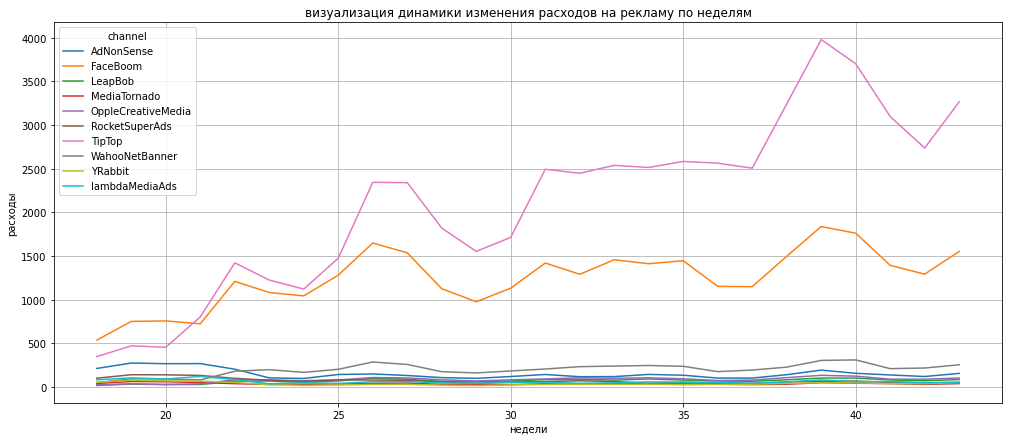

In [33]:
costs_weeks.pivot_table('costs', index='dt', columns='channel', aggfunc='sum').plot(grid=True, figsize=(17,7))
plt.title("визуализация динамики изменения расходов на рекламу по неделям")
plt.xlabel("недели")
plt.ylabel("расходы")

<div class="alert alert-success">
<b>Комментарий ревьюера ✔️:</b> Молодец, что показал динамику трат на одном графике </div>

In [34]:
costs_month = costs.copy(deep=True)
costs_month['dt'] = pd.to_datetime(costs_month['dt']).dt.month

Text(0, 0.5, 'расходы')

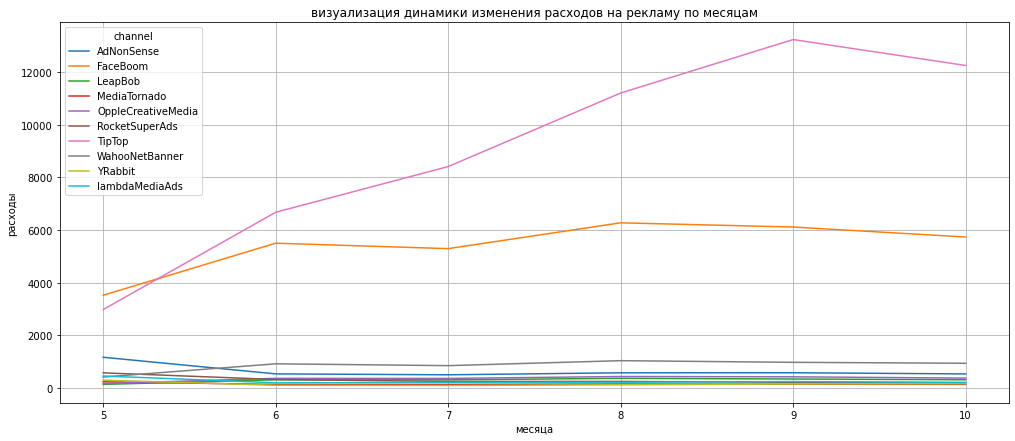

In [35]:
costs_month.pivot_table('costs', index='dt', columns='channel', aggfunc='sum').plot(grid=True, figsize=(17,7))
plt.title("визуализация динамики изменения расходов на рекламу по месяцам")
plt.xlabel("месяца")
plt.ylabel("расходы")

<div class="alert alert-warning">
<b>Комментарий ревьюера ⚠️:</b> Но тут все же нужно попарвить заголовок

<div class="alert alert-info"> <b>Комментарий студента:</b> Исправил на месяца </div>

In [35]:
#Узнайте, сколько в среднем стоило привлечение одного пользователя (CAC) из каждого источника.
#Используйте профили пользователей.

cac = (
    profiles.groupby('channel')
    .agg({'acquisition_cost': 'mean'})
    .rename(columns={'acquisition_cost': 'cac'})
)

cac.sort_values('cac', ascending=False)


,cac
channel,
TipTop,2.799003
FaceBoom,1.113286
AdNonSense,1.008054
lambdaMediaAds,0.724802
WahooNetBanner,0.602245
RocketSuperAds,0.412095
OppleCreativeMedia,0.250000
YRabbit,0.218975
MediaTornado,0.218717


In [36]:
# средняя стоимость привлечения без учета органического
cac_mean = (
    profiles.query('channel != "organic"').groupby('channel')
    .agg({'acquisition_cost': 'mean'})
    .rename(columns={'acquisition_cost': 'cac'})
)
cac_mean['cac'].mean()

0.7557348976115398

<div class="alert alert-success">
<b>Комментарий ревьюера ✔️:</b> Отлично посчитал САС как в общем, так и по источникам </div>

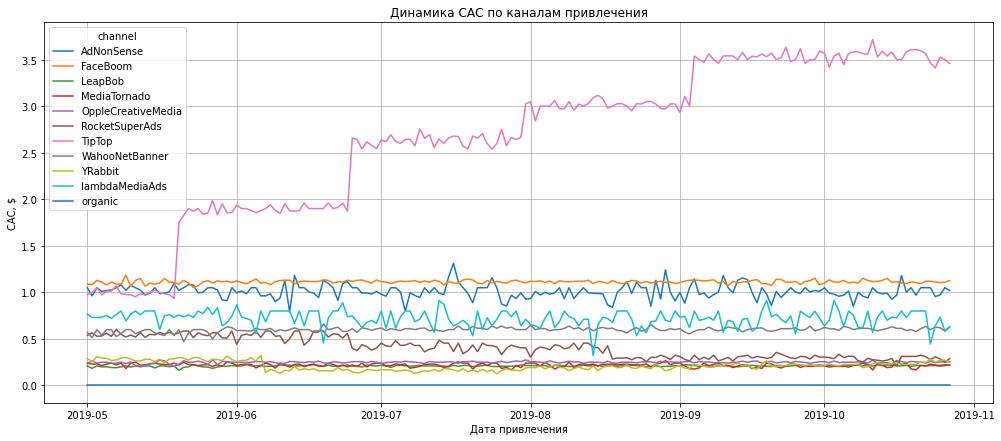

In [37]:
# динамика стоимости привлечения пользователей по каналам

profiles.pivot_table(
    index='dt', columns='channel', values='acquisition_cost', aggfunc='mean'
).plot(grid=True, figsize=(17, 7))
plt.ylabel('CAC, $')
plt.xlabel('Дата привлечения')
plt.title('Динамика САС по каналам привлечения')
plt.show()

<div class="alert alert-success">
<b>Комментарий ревьюера ✔️:</b> И визуализировал как надо </div>

    Вывод по шагу 4
    - Общая сумма расходов на маркетинг составила 105497.3 
    - Распределение трат по рекламным источникам склоняется в пользу 2х платформ TipTop (54751.30) 
    и FaceBoom (32445.60), что состовляет более 3/4 общих расходов на рекламу, что может быть проблемой 
    если они не дают достаточно платящих пользователей для окупаемости
    - В среднем привлечение одного пользователя (без учета органического) стоило 0.755, 
    но для платформы TipTop - 2.799, что подтверждает подозрение о проблеме с расходами на TipTop;
    Так как по данным шага 3 на TipTop приходилось 19561 привлеченных пользователя, из них 1878 платящих (9.60%), 
    а на FaceBoom со стоимостью привлечения в 1.113	- 29144 пользователя, из них 3557 платящих (12.20%)
    - По данным динамики стоимости привлечения видно, что стоимость привлечения в TipTop росла 4 раза и менее чем 
    за 4 месяца выросла в 3 раза, в отличии от остальных каналов
    

<div class="alert alert-success">
<b>Комментарий ревьюера ✔️:</b> Очень хорошо </div>

#### ШАГ 5  
##### оценка окупаемости рекламы
<a id='part_5'></a>

Используя графики LTV, ROI и CAC, проанализируйте окупаемость рекламы. 
Считайте, что на календаре 1 ноября 2019 года, а в бизнес-плане заложено, что пользователи должны окупаться не позднее чем через две недели после привлечения. 
Необходимость включения в анализ органических пользователей определите самостоятельно.

Проанализируйте окупаемость рекламы c помощью графиков LTV и ROI, а также графики динамики LTV, CAC и ROI.

Проверьте конверсию пользователей и динамику её изменения. То же самое сделайте с удержанием пользователей. 

Постройте и изучите графики конверсии и удержания.

Проанализируйте окупаемость рекламы с разбивкой по устройствам. Постройте графики LTV и ROI, а также графики динамики LTV, CAC и ROI.

Проанализируйте окупаемость рекламы с разбивкой по странам. Постройте графики LTV и ROI, а также графики динамики LTV, CAC и ROI.
Проанализируйте окупаемость рекламы с разбивкой по рекламным каналам. Постройте графики LTV и ROI, а также графики динамики LTV, CAC и ROI.
Ответьте на такие вопросы:
Окупается ли реклама, направленная на привлечение пользователей в целом?
Какие устройства, страны и рекламные каналы могут оказывать негативное влияние на окупаемость рекламы?
Чем могут быть вызваны проблемы окупаемости?

<div class="alert alert-danger">
<b>Комментарий ревьюера ❌:</b> Но здесь согласно логике проекта - следует провести фильтрацию органических пользователей, ведь мы анализируем расходы на рекламу, а органика нам ничего не стоила. 
    
Обрати, пожалуйста внимание на то, что после удаления органики часть графиков может несколько изменится и нужно будет скорректировать выводы

<div class="alert alert-info"> <b>Комментарий студента:</b> Исправил profiles </div>

In [54]:
observation_date = datetime(2019, 10, 1).date()  # момент анализа
horizon_days = 14

In [39]:
# для дальейщей работы убираем пользователей привлеченных органически, 
# так как нужно проанализировать эффективность рекламы
profiles = profiles.query('channel != "organic"')

<div class="alert alert-success">
<b>Комментарий ревьюера ✔️:</b> А вот дата и горизонт указаны, тут все классно</div>

<div class="alert alert-danger">
<b>Комментарий ревьюера ❌:</b> Далее каждая группа графиков построена правильно, но после каждой из них нужно написать тезисные выводы, сейчас менеджеру будет довольно сложно по ним ориентироваться.

<div class="alert alert-info"> <b>Комментарий студента:</b> Выводы добавил </div>

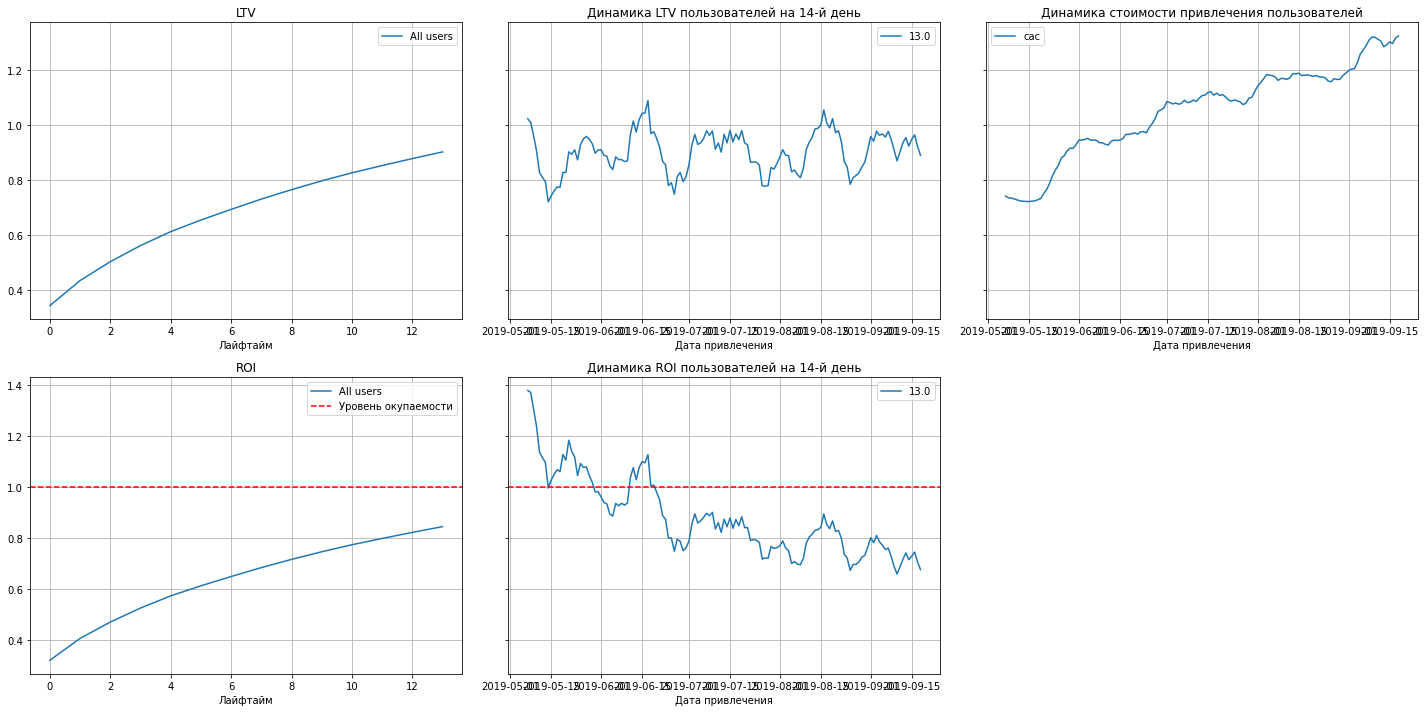

In [55]:
#Проанализируйте окупаемость рекламы c помощью графиков LTV и ROI, а также графики динамики LTV, CAC и ROI.
# считаем LTV и ROI
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles, orders, observation_date, horizon_days
)

# строим графики
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days)

    Вывод по LTV и ROI и их динамике
    - LTV и ROI положительные, но в целом окупаемость на 14 день не достигается (только на 20)
    - связано с тем, что динамика окупаемости снижается, а стоимость привлечения новых пользователей растет
    есть проблемы с рекламными затратами

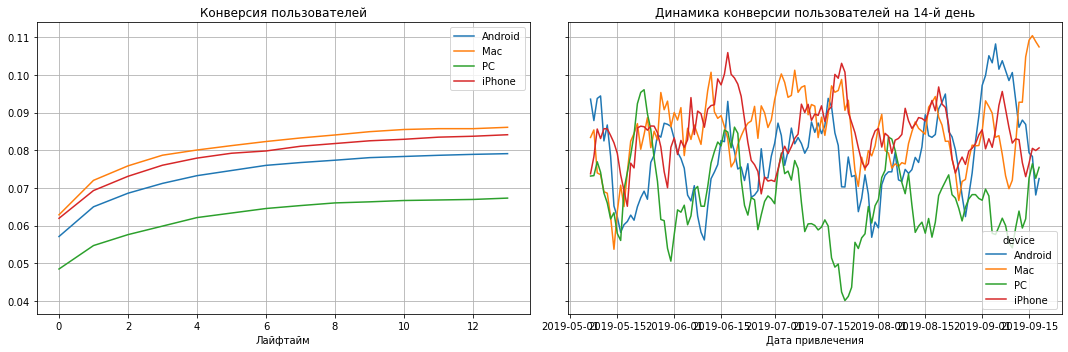

In [56]:
#Проверьте конверсию пользователей и динамику её изменения. То же самое сделайте с удержанием пользователей.
# смотрим конверсию с разбивкой по устройствам

dimensions = ['device']

conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_conversion(conversion_grouped, conversion_history, horizon_days)

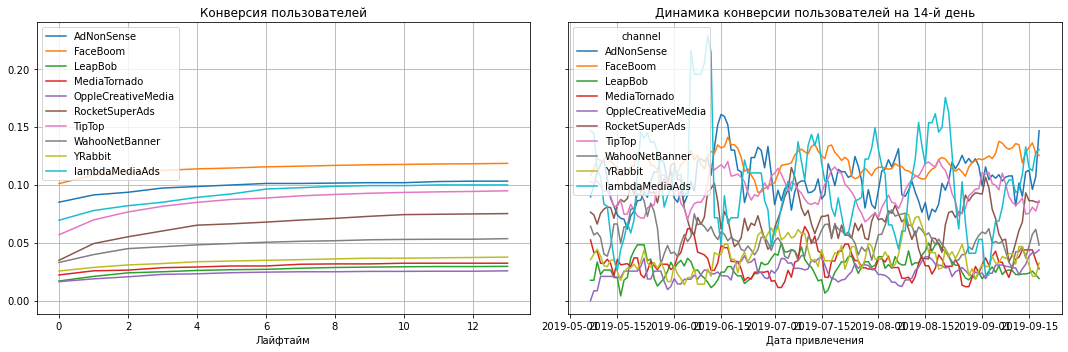

In [57]:
# смотрим конверсию с разбивкой по каналам привлечения

dimensions = ['channel']

conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_conversion(conversion_grouped, conversion_history, horizon_days)

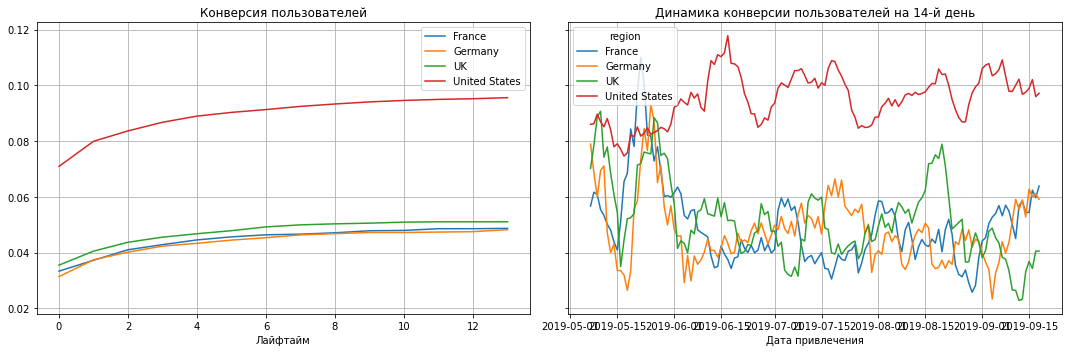

In [58]:
# смотрим конверсию с разбивкой по регионам

dimensions = ['region']

conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_conversion(conversion_grouped, conversion_history, horizon_days)

     Вывод по конверсии
    - Конверсия по регионам:
        - Выделяется США с лучшими показателем около 10%, остальные страны стабильно дают 5%
        - Из каналов привлечения можно выделить AdNonSense, FaceBoom, TipTop и LambdaMediaAds (около 10%)
        - Конверсия пользователей PC заметно ниже, хотя по количеству сопоставимо с пользователями Mac
    - Есть вероятность, что пользователи из Франции, Германии и Англии сталкиваются с трудностями при оплате.
    - Стоит больше использовать AdNonSense, FaceBoom, TipTop и LambdaMediaAds в качестве каналов привлечения, 
    AdNonSense и LambdaMediaAds имееют приемущество за счет низкой цены привлечения

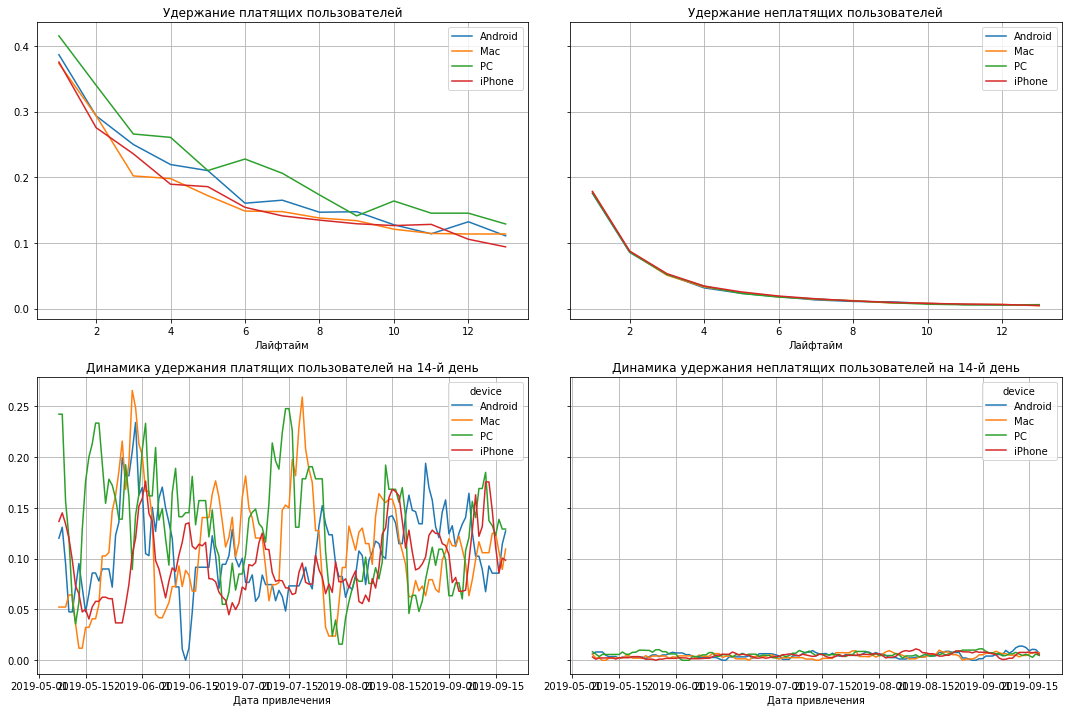

In [44]:
# смотрим удержание с разбивкой по устройствам

dimensions = ['device']

retention_raw, retention_grouped, retention_history = get_retention(
    profiles, visits, observation_date, horizon_days, dimensions=dimensions
)

plot_retention(retention_grouped, retention_history, horizon_days)

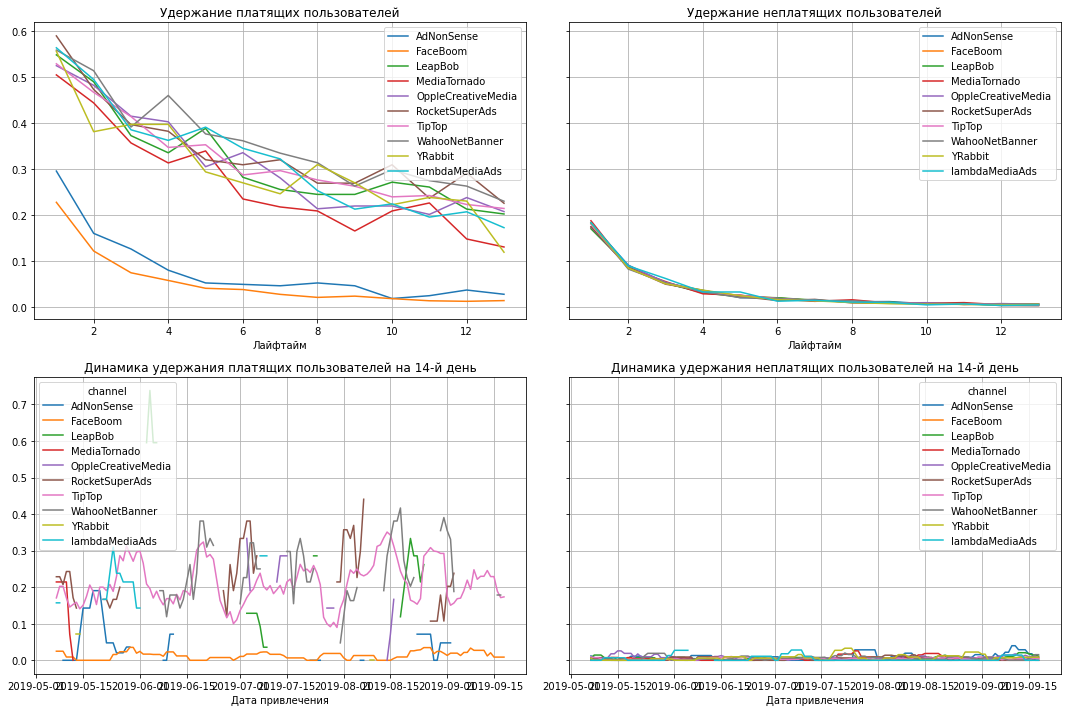

In [45]:
dimensions = ['channel']

retention_raw, retention_grouped, retention_history = get_retention(
    profiles, visits, observation_date, horizon_days, dimensions=dimensions
)

plot_retention(retention_grouped, retention_history, horizon_days)

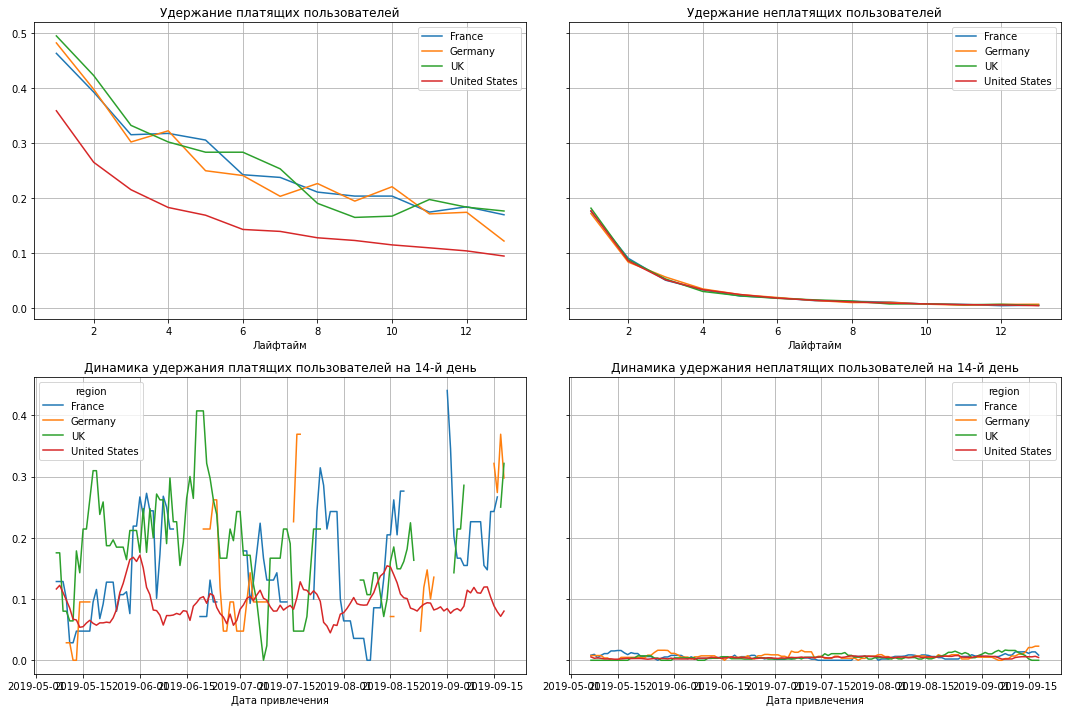

In [46]:
dimensions = ['region']

retention_raw, retention_grouped, retention_history = get_retention(
    profiles, visits, observation_date, horizon_days, dimensions=dimensions
)

plot_retention(retention_grouped, retention_history, horizon_days)

     Вывод по удержанию
    - Удержание по регионам:
        - Выделяется США с худшими показателями, остальные страны стабильны
        - Из каналов привлечения хуже всего AdNonSense и FaceBoom
        - Отличий в зависимости от устройства не обнаружено
    - Получается, что пользователям из США и пользователям привлеченные через AdNonSense и FaceBoom, 
    что то не нравится или они не понимают как работает приложение; возможно проблемы с локализацией 
    и рекламными компаниями в данных каналах.
    - В остальном с удержанием все в среднем стабильно

In [46]:
#окупаемость 

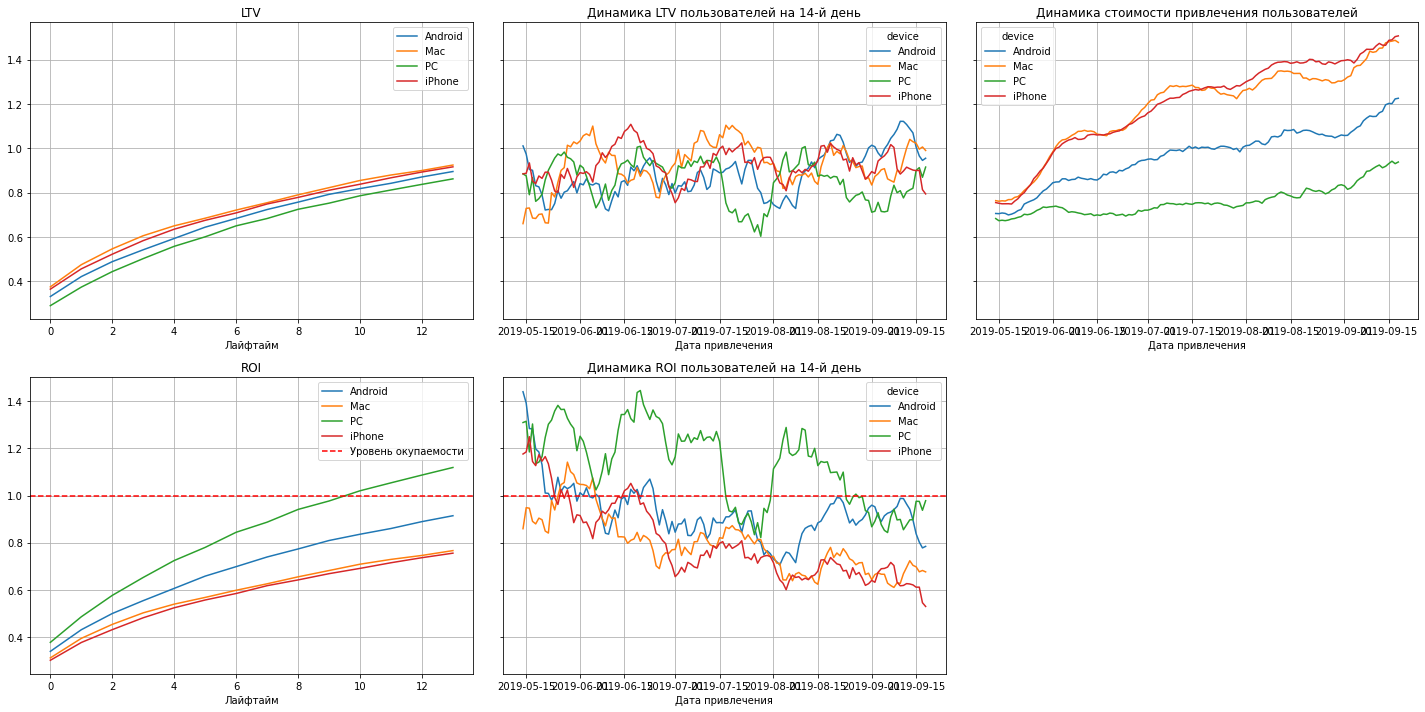

In [48]:
# смотрим окупаемость с разбивкой по устройствам

dimensions = ['device'] 

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
)

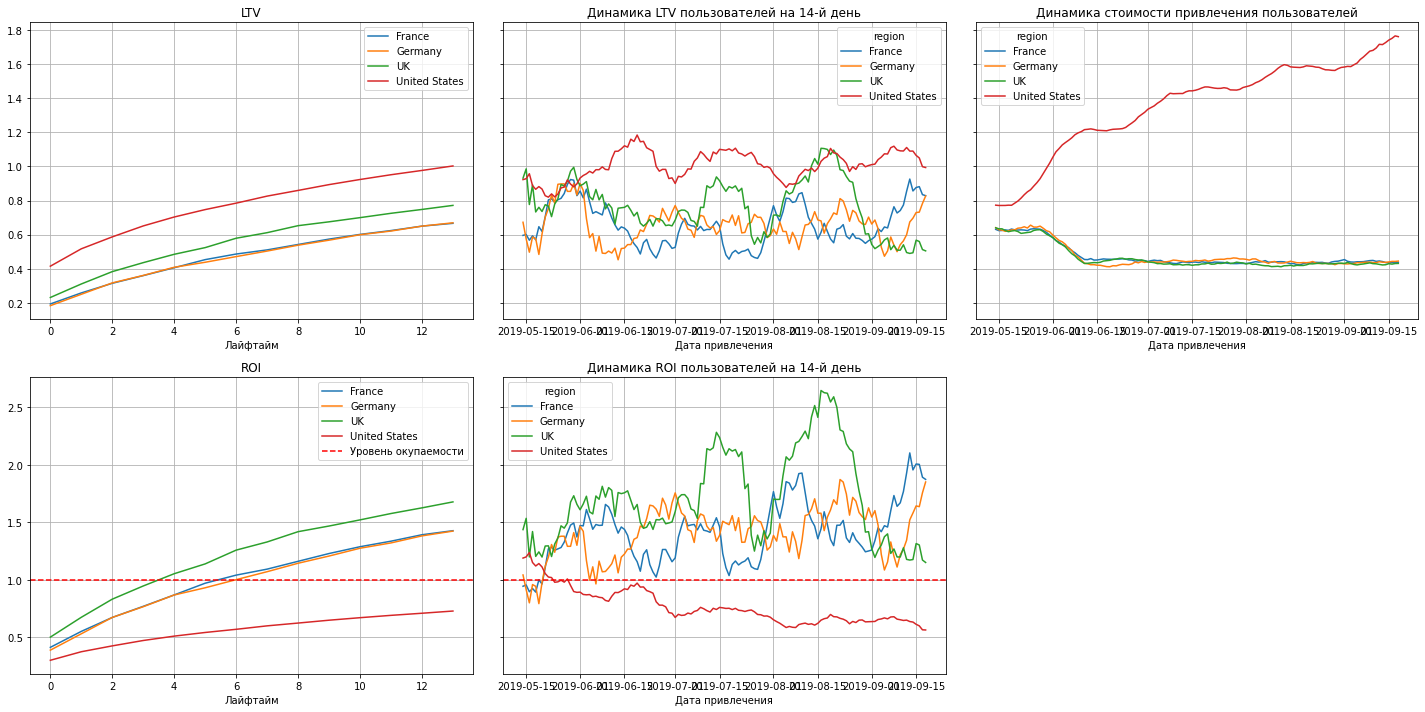

In [49]:
# смотрим окупаемость с разбивкой по странам

dimensions = ['region'] 

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
)

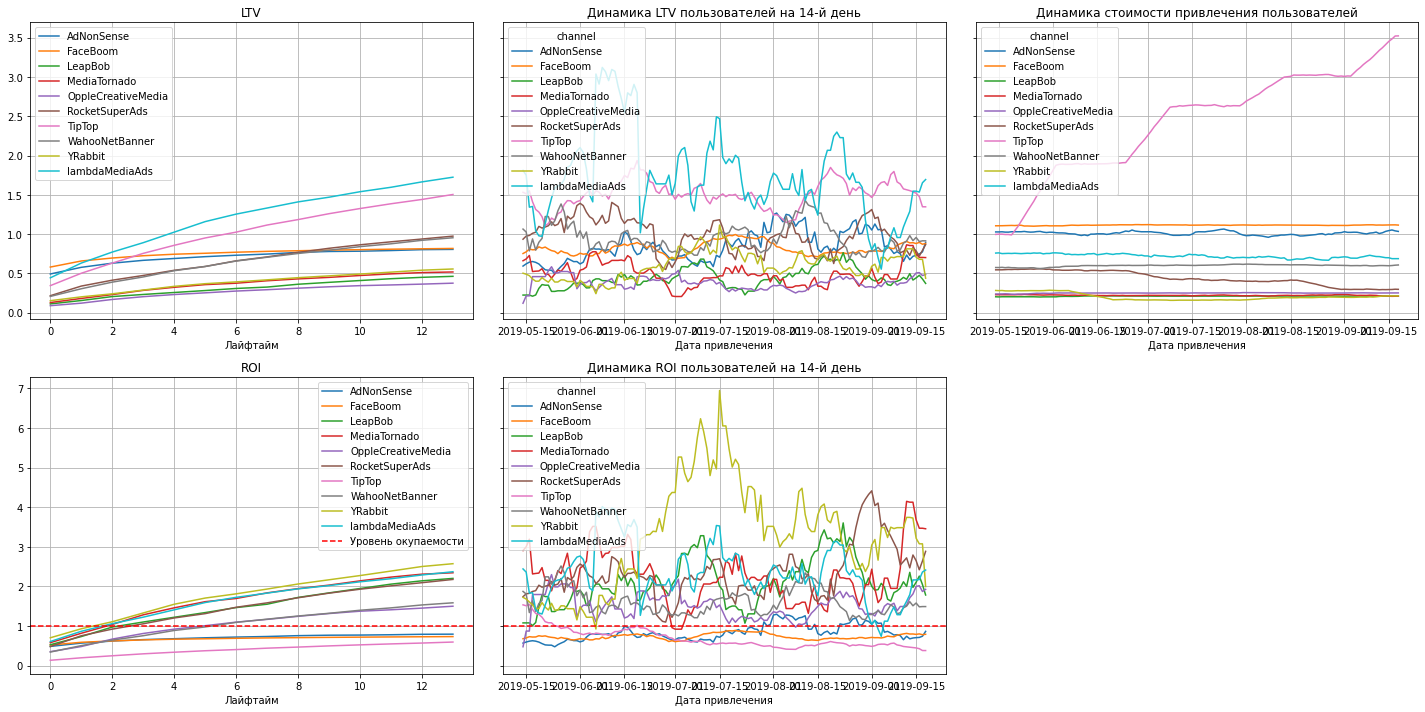

In [50]:
# смотрим окупаемость с разбивкой по каналам привлечения

dimensions = ['channel'] 

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
)

Ответьте на такие вопросы: Окупается ли реклама, направленная на привлечение пользователей в целом? Какие устройства, страны и рекламные каналы могут оказывать негативное влияние на окупаемость рекламы? Чем могут быть вызваны проблемы окупаемости?

#### ВЫВОД 

<a id='sum'></a>

    Вывод по шагу 5 и общий вывод
    - В целом реклама на 14й день, по заданию не окупается (LTV и ROI положительные, 
    но в целом окупаемость на 14 день не достигается (только на 20)), но:
        - Есть проблема с каналом привлечения TipTop, который расходует половину рекламного бюджета, но не дает 
        достаточного притока платящих пользователй, если его отключить, то окупаемость может снизиться до 10 дней
    
    - Нужно проверить причины низкого удержания пользователей из США, 
    так как они дают самый высокий процент конверсии, если поднять удержание - поднимется окупаемость 
    
    - Нужно проверить причины низкой конверсии пользователей из Франции, Германии и Англии,
    при высоком уровне удержания - они реже платят
   
    - Из каналов привлечения выделяются AdNonSense, FaceBoom и LambdaMediaAds - с самыми высокими уровнями 
    конверсии и окупаемой ценой
   
    - Ниже приведен график окупаемости, где я исключил выпадающие канал привлечения,
    самый лучший результат можно получить - отказавщись от TipTop или провести его настройку 

<div class="alert alert-danger">
<b>Комментарий ревьюера ❌:</b> Неплохо, но после чуть более детально описания графиков лучше будет немного дополнить общий вывод. Также, сейчас нет никаких рекомендаций по "хорошим" каналам, указаны только проблемные каналы и что с ними стоит сделать.

<div class="alert alert-success">
<b>Комментарий ревьюера ✔️:</b> Илья, проект отличный! У тебя очень сильные аналитические навыки, владение инструментами для проведения исследования и навыки продуктовой аналитики. Но всё же в проекте есть несколько замечаний и я попрошу тебя исправить их, чтобы он стал еще лучше! </div>

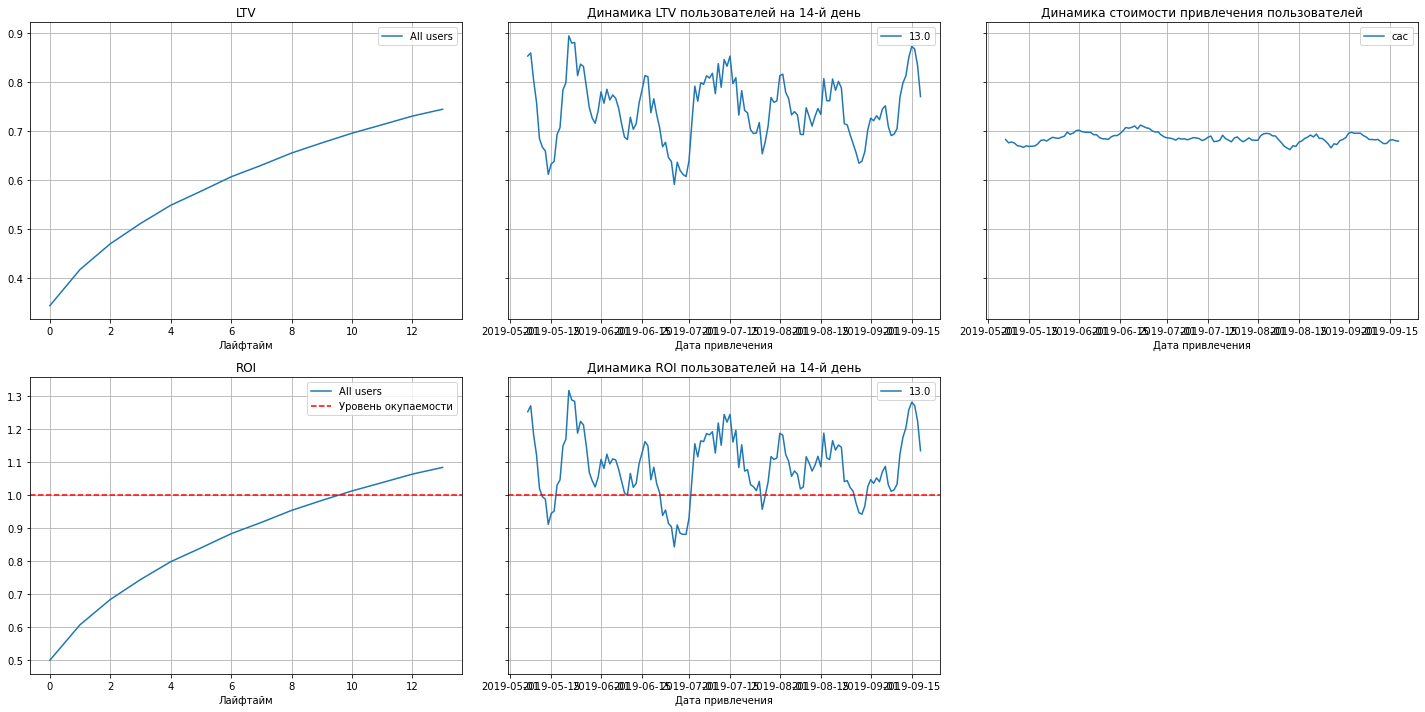

In [51]:
# без TipTop
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles.query('channel != "TipTop"'), orders, observation_date, horizon_days
)

# строим графики
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days)


<div class="alert alert-success">
<b>Комментарий ревьюера ✔️:</b> Но молодец, что провел анализ без TipTop, это действительно отличный способ фильтрации</div>